# Stock Data Exploration
Before building the model, we explore the data to understand:
- What the data looks like
- Any missing values
- Price trends
- Volume patterns
- Feature correlations

## Step 1 — Install & Import Libraries

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2 — Fetch Stock Data

In [ ]:
TICKER = 'AAPL'  

stock = yf.Ticker(TICKER)
df = stock.history(period='2y')
df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
df.dropna(inplace=True)

print(f'Ticker : {TICKER}')
print(f'Rows   : {len(df)}')
print(f'From   : {df.index[0].date()}')
print(f'To     : {df.index[-1].date()}')

Ticker : AAPL
Rows   : 502
From   : 2024-03-11
To     : 2026-03-11


## Step 3 — First Look at the Data

In [ ]:
df.head()

,Open,High,Low,Close,Volume
Date,,,,,
2024-03-11 00:00:00-04:00,171.380290,172.807306,170.498318,171.192001,60139500
2024-03-12 00:00:00-04:00,171.588399,172.460467,169.467699,171.667679,59825400
2024-03-13 00:00:00-04:00,171.211848,171.628059,169.219966,169.586639,52488700
2024-03-14 00:00:00-04:00,171.350574,172.737941,170.498329,171.439758,72913500
2024-03-15 00:00:00-04:00,169.626267,171.063187,168.754198,171.063187,121752700


In [ ]:
df.tail()

,Open,High,Low,Close,Volume
Date,,,,,
2026-03-05 00:00:00-05:00,260.790009,261.559998,257.250000,260.290009,49658600
2026-03-06 00:00:00-05:00,258.630005,258.769989,254.369995,257.459991,41120000
2026-03-09 00:00:00-04:00,255.690002,261.149994,253.679993,259.880005,38218500
2026-03-10 00:00:00-04:00,257.649994,262.480011,256.950012,260.829987,30537200
2026-03-11 00:00:00-04:00,261.209991,262.130005,259.549988,260.070007,12405401


In [ ]:
print('Shape:', df.shape)
print()
df.info()

Shape: (502, 5)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 502 entries, 2024-03-11 00:00:00-04:00 to 2026-03-11 00:00:00-04:00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    502 non-null    float64
 1   High    502 non-null    float64
 2   Low     502 non-null    float64
 3   Close   502 non-null    float64
 4   Volume  502 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 23.5 KB


In [6]:
# Basic statistics — min, max, mean etc
df.describe().round(2)

,Open,High,Low,Close,Volume
count,502.00,502.00,502.00,502.00,5.020000e+02
mean,225.85,228.30,223.64,226.05,5.466148e+07
std,29.31,29.38,29.10,29.27,2.721766e+07
min,163.86,164.90,162.60,163.51,1.240540e+07
25%,207.80,210.71,205.52,208.09,4.005735e+07
50%,225.83,227.88,223.50,225.85,4.809625e+07
75%,247.05,249.38,244.61,246.93,5.980215e+07
max,285.93,288.35,283.04,285.92,3.186799e+08


## Step 4 — Check for Missing Values

In [7]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing)

if missing.sum() == 0:
    print('\nNo missing values found!')
else:
    print('\nWarning: Missing values found, need to handle them.')

Missing values per column:
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

No missing values found!


## Step 5 — Plot the Closing Price

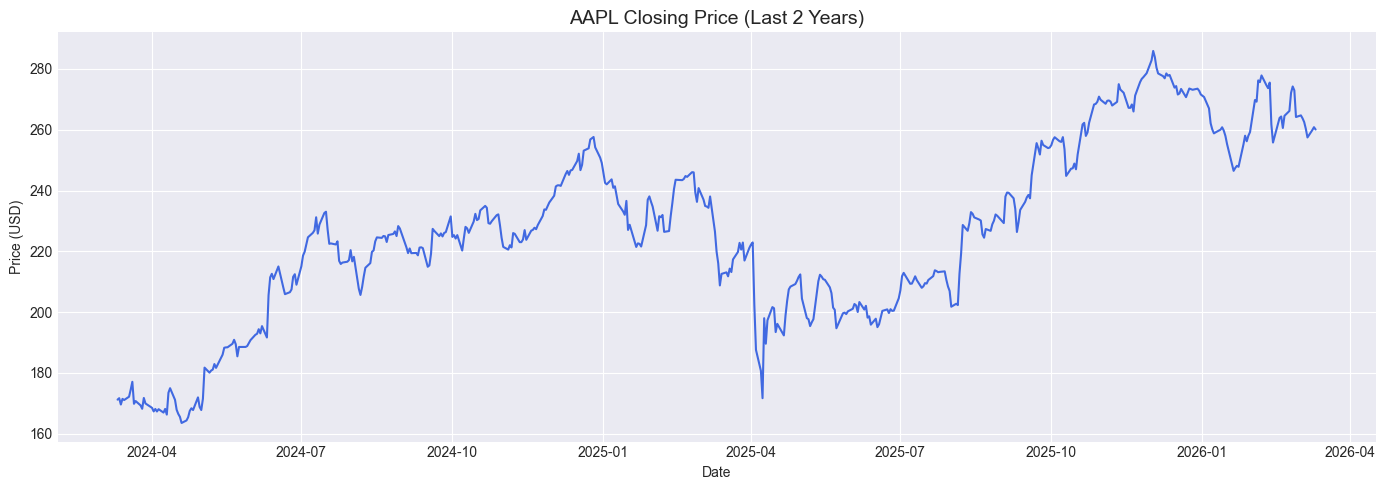

In [8]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Close'], color='royalblue', linewidth=1.5)
plt.title(f'{TICKER} Closing Price (Last 2 Years)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.show()

## Step 6 — Plot Volume

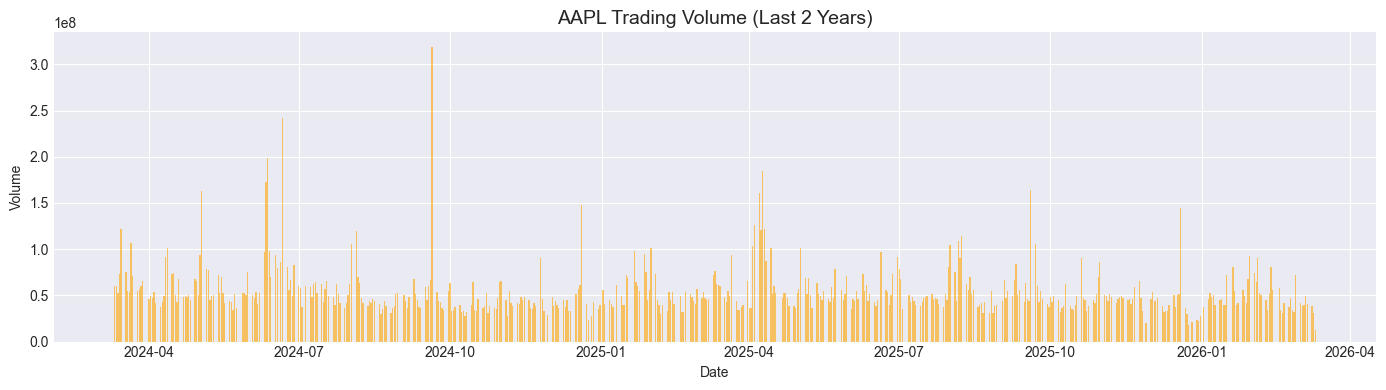

In [9]:
plt.figure(figsize=(14, 4))
plt.bar(df.index, df['Volume'], color='orange', alpha=0.6)
plt.title(f'{TICKER} Trading Volume (Last 2 Years)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Volume')
plt.tight_layout()
plt.show()

## Step 7 — Add Moving Averages & Visualize

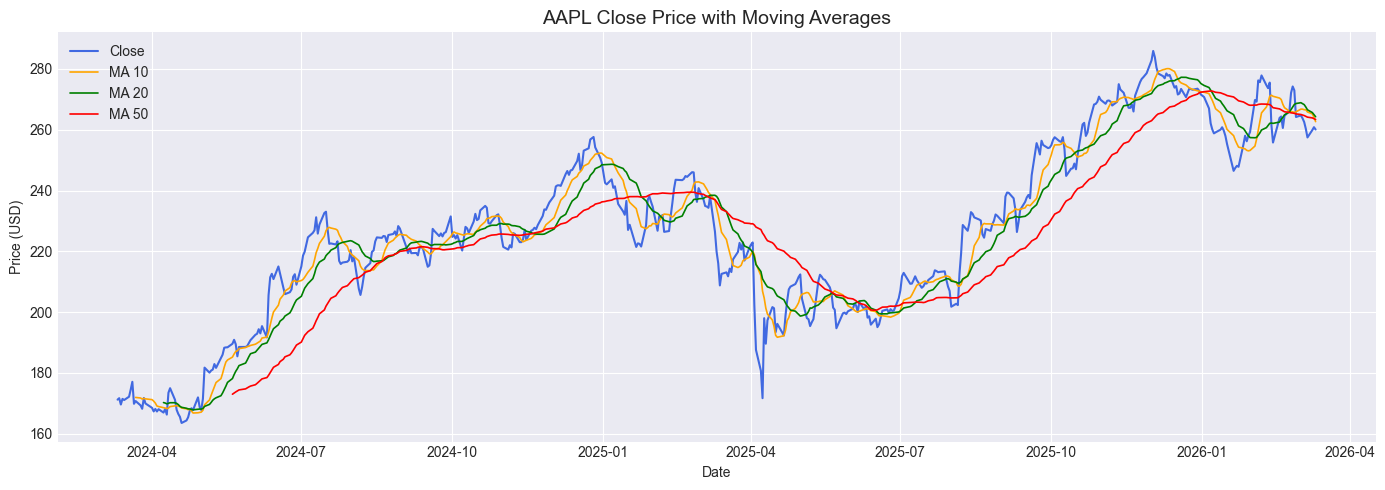

In [10]:
df['MA_10'] = df['Close'].rolling(window=10).mean()
df['MA_20'] = df['Close'].rolling(window=20).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()

plt.figure(figsize=(14, 5))
plt.plot(df['Close'],  label='Close',  linewidth=1.5, color='royalblue')
plt.plot(df['MA_10'],  label='MA 10',  linewidth=1.2, color='orange')
plt.plot(df['MA_20'],  label='MA 20',  linewidth=1.2, color='green')
plt.plot(df['MA_50'],  label='MA 50',  linewidth=1.2, color='red')
plt.title(f'{TICKER} Close Price with Moving Averages', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

## Step 8 — Daily Returns Distribution

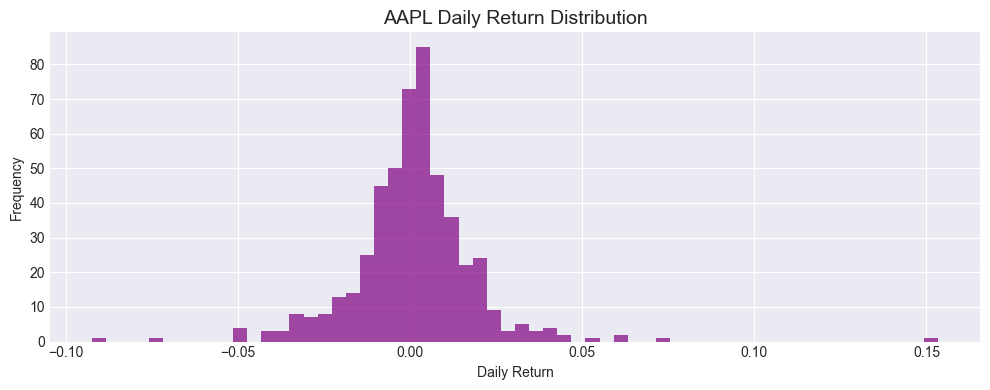

Average daily return : 0.0010
Std deviation        : 0.0179
Max single day gain  : 0.1533
Max single day loss  : -0.0925


In [11]:
df['Return_1d'] = df['Close'].pct_change(1)

plt.figure(figsize=(10, 4))
df['Return_1d'].hist(bins=60, color='purple', alpha=0.7)
plt.title(f'{TICKER} Daily Return Distribution', fontsize=14)
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f'Average daily return : {df["Return_1d"].mean():.4f}')
print(f'Std deviation        : {df["Return_1d"].std():.4f}')
print(f'Max single day gain  : {df["Return_1d"].max():.4f}')
print(f'Max single day loss  : {df["Return_1d"].min():.4f}')

## Step 9 — Correlation Heatmap

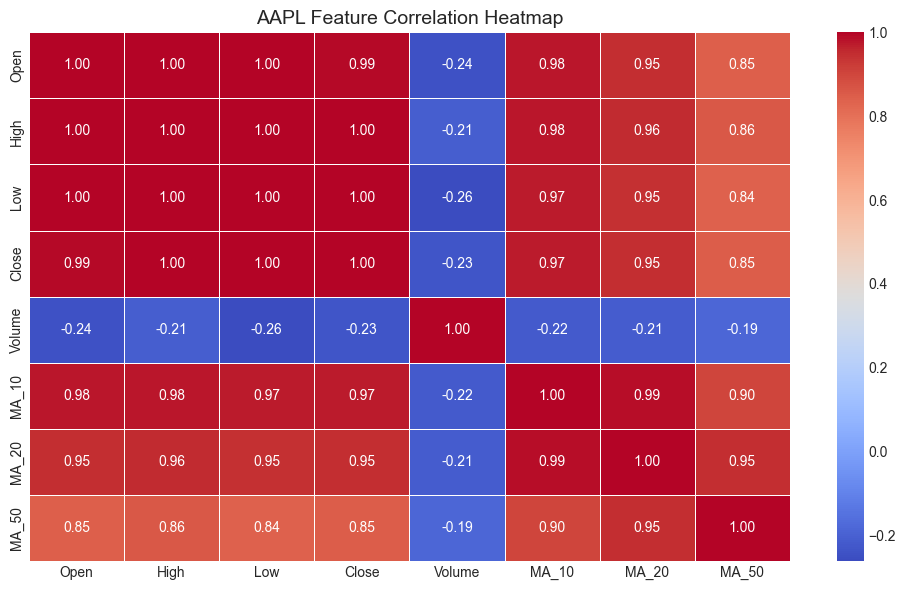

In [12]:
corr = df[['Open', 'High', 'Low', 'Close', 'Volume', 'MA_10', 'MA_20', 'MA_50']].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title(f'{TICKER} Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

## Step 10 — Summary & Key Observations

In [13]:
print('===== DATA SUMMARY =====')
print(f'Ticker             : {TICKER}')
print(f'Total trading days : {len(df)}')
print(f'Date range         : {df.index[0].date()} → {df.index[-1].date()}')
print(f'Lowest close price : ${df["Close"].min():.2f}')
print(f'Highest close price: ${df["Close"].max():.2f}')
print(f'Current price      : ${df["Close"].iloc[-1]:.2f}')
print(f'Avg daily volume   : {df["Volume"].mean():,.0f}')
print(f'Missing values     : {df.isnull().sum().sum()}')
print('========================')
print('Data looks good! Ready to train the model.')

===== DATA SUMMARY =====
Ticker             : AAPL
Total trading days : 502
Date range         : 2024-03-11 → 2026-03-11
Lowest close price : $163.51
Highest close price: $285.92
Current price      : $260.07
Avg daily volume   : 54,661,477
Missing values     : 78
Data looks good! Ready to train the model.
